TRAIN/TEST PIPELINE SAU KHI KHẮC PHỤC DATA LEAKAGE

-Lọc phạm vi modeling bằng các thông tin chỉ có tại thời điểm T0: chỉ sử dụng các giao dịch TRANSFER/CASH_OUT và thông tin của tài khoản nhận (Customer).

-Chia tập train/test theo thời gian (step), không sử dụng random split.

-Cân bằng lớp (class balancing) chỉ thực hiện trên tập train.

-Các đặc trưng (features) đưa vào mô hình được quản lý thông qua danh sách whitelist trong src.features.MODEL_FEATURE_COLUMNS; các cột dữ liệu thô (raw columns) và cột isFlaggedFraud không được đưa vào mô hình.

CHÚNG TA CŨNG SẼ SỬ DỤNG BA THUẬT TOÁN:

Random Forest: xử lý tốt dữ liệu mất cân bằng; ít bị overfitting.

XGBoost: rất mạnh, ổn định, ít cần tuning vẫn tốt, dataset vừa

LightGBM: rất nhanh, hiệu năng cao, dễ overfitting, dataset lớn



Import thư viện

Load data

In [1]:
import sys
from pathlib import Path
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier


In [2]:
PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / 'src').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

sys.path.insert(0, str(PROJECT_ROOT))

from src.data_loader import (
    load_paysim_data,
    filter_modeling_scope,
    split_by_time,
    balance_training_data,
)

DATA_PATH = PROJECT_ROOT / 'data' / 'raw' / 'Synthetic_Financial_datasets_log.csv'

df = load_paysim_data(DATA_PATH)
df_scope = filter_modeling_scope(df)
train_raw, test_raw = split_by_time(df_scope, test_size=0.2)
train_raw_balanced = balance_training_data(train_raw, negative_multiplier=3)

print('Modeling scope rows:', len(df_scope))
print('Train rows before balancing:', len(train_raw))
print('Train rows after balancing:', len(train_raw_balanced))
print('Test rows:', len(test_raw))
print('Train fraud rate after balancing:', train_raw_balanced['isFraud'].mean())
print('Test fraud rate:', test_raw['isFraud'].mean())
print('Train step range:', int(train_raw['step'].min()), int(train_raw['step'].max()))
print('Test step range:', int(test_raw['step'].min()), int(test_raw['step'].max()))


--- Đang tải dữ liệu từ: D:\Công việc\DA + DE\Book DA\Data Science for Business\PaySim\fraud-detection-paysim\data\raw\Synthetic_Financial_datasets_log.csv ---


Bộ nhớ tiêu thụ ban đầu: 533.97 MB


Bộ nhớ tiêu thụ sau tối ưu: 248.78 MB
Tiết kiệm được: 53.4%


Modeling scope rows: 2770409
Train rows before balancing: 2198953
Train rows after balancing: 15772
Test rows: 571456
Train fraud rate after balancing: 0.25
Test fraud rate: 0.007472141337215813
Train step range: 1 353
Test step range: 354 743


Gọi Feature

In [3]:
from src.features import build_features, split_xy, MODEL_FEATURE_COLUMNS

train_features = build_features(train_raw_balanced)
test_features = build_features(test_raw)

print('Model features:', MODEL_FEATURE_COLUMNS)
print('Train feature columns:', list(train_features.columns))
print('Test feature columns:', list(test_features.columns))


Model features: ['amount', 'is_high_risk_type', 'log_amount', 'hour', 'is_night', 'is_dest_zero_balance', 'high_risk_combo']
Train feature columns: ['amount', 'is_high_risk_type', 'log_amount', 'hour', 'is_night', 'is_dest_zero_balance', 'high_risk_combo', 'isFraud']
Test feature columns: ['amount', 'is_high_risk_type', 'log_amount', 'hour', 'is_night', 'is_dest_zero_balance', 'high_risk_combo', 'isFraud']


Split X,y


In [4]:
Xf_train, yf_train = split_xy(train_features)
Xf_test, yf_test = split_xy(test_features)

# Kept for downstream notebook cells that inspect feature names.
Xf, yf = Xf_train, yf_train

print('X train shape:', Xf_train.shape)
print('X test shape:', Xf_test.shape)


X train shape: (15772, 7)
X test shape: (571456, 7)


Train/test split

In [5]:
print('Chronological split validated:')
print('Train max step:', int(train_raw['step'].max()))
print('Test min step:', int(test_raw['step'].min()))
assert train_raw['step'].max() < test_raw['step'].min()


Chronological split validated:
Train max step: 353
Test min step: 354


Hàm train + giá trị cốt lõi


In [6]:
def evaluate_model(model, X_train, X_test, y_train, y_test, name="Model"):
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    print(f"\n==== {name} ====")
    print(classification_report(y_test, y_pred))

    auc = roc_auc_score(y_test, y_proba)
    print("ROC-AUC:", auc)

    return auc

Trong gian lận tài chính nên tập trung vào:

Precision: khi mô hình báo là gian lận, thì bao nhiêu % là đúng thật (tránh làm phiền khách hàng tốt)

Recall (Khả năng bắt sóng): Trong tất cả các vụ gian lận thực tế, mô hình bắt được bao nhiêu vụ? (Tránh thất thoát tiền cho ngân hàng)

AUC (Area Under Curve) đo lường khả năng mô hình phân biệt giữa "người tốt" và "kẻ xấu". AUC = 0.5 là dự báo ngẫu nhiên, AUC càng gần 1 thì mô hình càng hoàn hảo trong việc tách bạch hai nhóm này

# Train 

Random Forest

In [7]:
rf = RandomForestClassifier(n_estimators= 100, random_state= 42)
auc_rf_g = evaluate_model(rf, Xf_train, Xf_test, yf_train, yf_test, "RF")


==== RF ====


              precision    recall  f1-score   support

           0       1.00      0.91      0.95    567186
           1       0.05      0.66      0.10      4270

    accuracy                           0.91    571456
   macro avg       0.52      0.78      0.52    571456
weighted avg       0.99      0.91      0.95    571456



ROC-AUC: 0.8720028168811471


XGBoost

In [8]:
xgb = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    use_label_encoder=False,
    eval_metric= 'logloss'
)

auc_xgb_g = evaluate_model(xgb,Xf_train, Xf_test, yf_train, yf_test, "XGB" )

C:\Users\admin\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\training.py:199: UserWarning: [18:54:27] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



==== XGB ====


              precision    recall  f1-score   support

           0       1.00      0.95      0.97    567186
           1       0.09      0.66      0.16      4270

    accuracy                           0.95    571456
   macro avg       0.54      0.81      0.57    571456
weighted avg       0.99      0.95      0.97    571456

ROC-AUC: 0.9040884927191111


LightGBM

In [9]:
lgb = LGBMClassifier(
    n_estimators=100,
    learning_rate=0.1,
    random_state=42
)

auc_lgb_g = evaluate_model(lgb, Xf_train, Xf_test, yf_train, yf_test, "LGB")

C:\Users\admin\AppData\Local\Programs\Python\Python313\Lib\site-packages\joblib\externals\loky\backend\context.py:131: UserWarning: Could not find the number of physical cores for the following reason:
found 0 physical cores < 1
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\Users\admin\AppData\Local\Programs\Python\Python313\Lib\site-packages\joblib\externals\loky\backend\context.py", line 255, in _count_physical_cores
    raise ValueError(f"found {cpu_count_physical} physical cores < 1")


[LightGBM] [Info] Number of positive: 3943, number of negative: 11829
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000775 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 540
[LightGBM] [Info] Number of data points in the train set: 15772, number of used features: 6
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.250000 -> initscore=-1.098612
[LightGBM] [Info] Start training from score -1.098612



==== LGB ====


              precision    recall  f1-score   support

           0       1.00      0.95      0.97    567186
           1       0.09      0.66      0.15      4270

    accuracy                           0.95    571456
   macro avg       0.54      0.80      0.56    571456
weighted avg       0.99      0.95      0.97    571456

ROC-AUC: 0.9036441308494921


In [10]:
results = {
    "RF_focus": auc_rf_g,
    "XGB_focus": auc_xgb_g,
    "LGB_focus": auc_lgb_g,
}

results

{'RF_focus': 0.8720028168811471,
 'XGB_focus': 0.9040884927191111,
 'LGB_focus': 0.9036441308494921}

Ta có thể thấy LGB tốt nhất về mặt chỉ số do nó học từ những sai lầm (errors) của các cây quyết định trước đó, giúp nó "tinh vi" hơn trong việc nhận diện các mẫu gian lận lắt léo

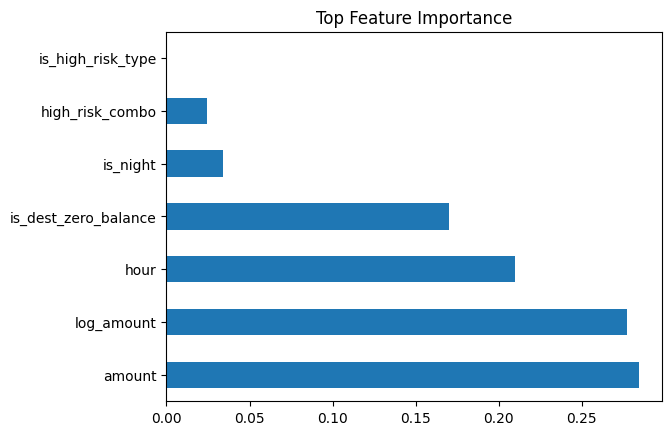

In [11]:
import matplotlib.pyplot as plt
import pandas as pd

importances = pd.Series(rf.feature_importances_, index=Xf.columns)
importances.nlargest(10).plot(kind='barh')
plt.title("Top Feature Importance")
plt.show()

[RF - Focus] Average Precision (AP): 0.2086
[RF - Focus] F1-Score: 0.0974


[XGB - Focus] Average Precision (AP): 0.3981
[XGB - Focus] F1-Score: 0.1581


[LGB - Focus] Average Precision (AP): 0.3955
[LGB - Focus] F1-Score: 0.1549


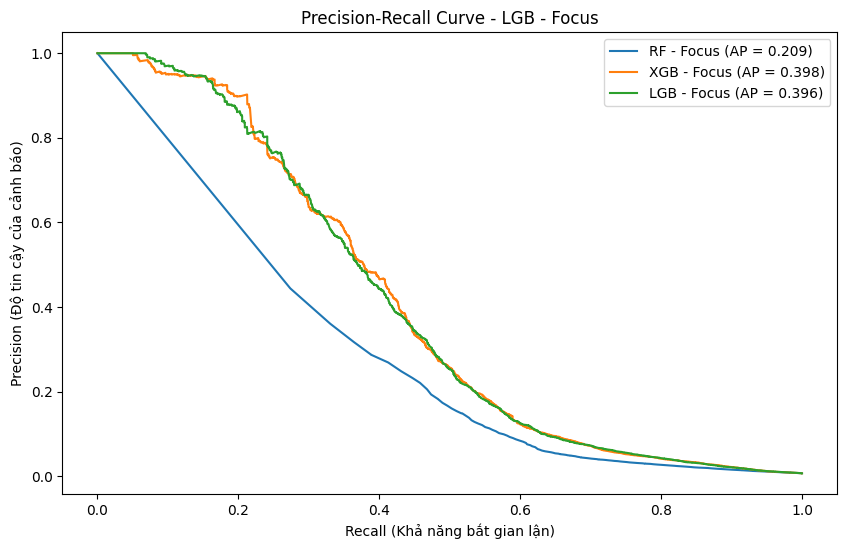

In [12]:
from sklearn.metrics import precision_recall_curve, average_precision_score, f1_score
import matplotlib.pyplot as plt

def evaluate_precision_recall(model, X_test, y_test, name="Model"):
    # Lấy xác suất dự báo cho lớp 1 (Fraud)
    y_proba = model.predict_proba(X_test)[:, 1]
    y_pred = model.predict(X_test)
    
    # Tính toán các giá trị PR
    precision, recall, thresholds = precision_recall_curve(y_test, y_proba)
    avg_precision = average_precision_score(y_test, y_proba)
    f1 = f1_score(y_test, y_pred)
    
    # Vẽ biểu đồ
    plt.plot(recall, precision, label=f'{name} (AP = {avg_precision:.3f})')
    plt.xlabel('Recall (Khả năng bắt gian lận)')
    plt.ylabel('Precision (Độ tin cậy của cảnh báo)')
    plt.title(f'Precision-Recall Curve - {name}')
    plt.legend(loc='best')
    
    print(f"[{name}] Average Precision (AP): {avg_precision:.4f}")
    print(f"[{name}] F1-Score: {f1:.4f}")
    
    return avg_precision, f1

# Chạy đánh giá cho 3 mô hình trên tập Focus
plt.figure(figsize=(10, 6))
ap_rf, f1_rf = evaluate_precision_recall(rf, Xf_test, yf_test, "RF - Focus")
ap_xgb, f1_xgb = evaluate_precision_recall(xgb, Xf_test, yf_test, "XGB - Focus")
ap_lgb, f1_lgb = evaluate_precision_recall(lgb, Xf_test, yf_test, "LGB - Focus")
plt.show()

Profit Curve dùng để chọn threshold theo chi phí (cost) hiện tại.

ROC Curve và Lift Curve dùng để theo dõi năng lực xếp hạng (ranking ability) của mô hình khi base rate hoặc cost matrix thay đổi.


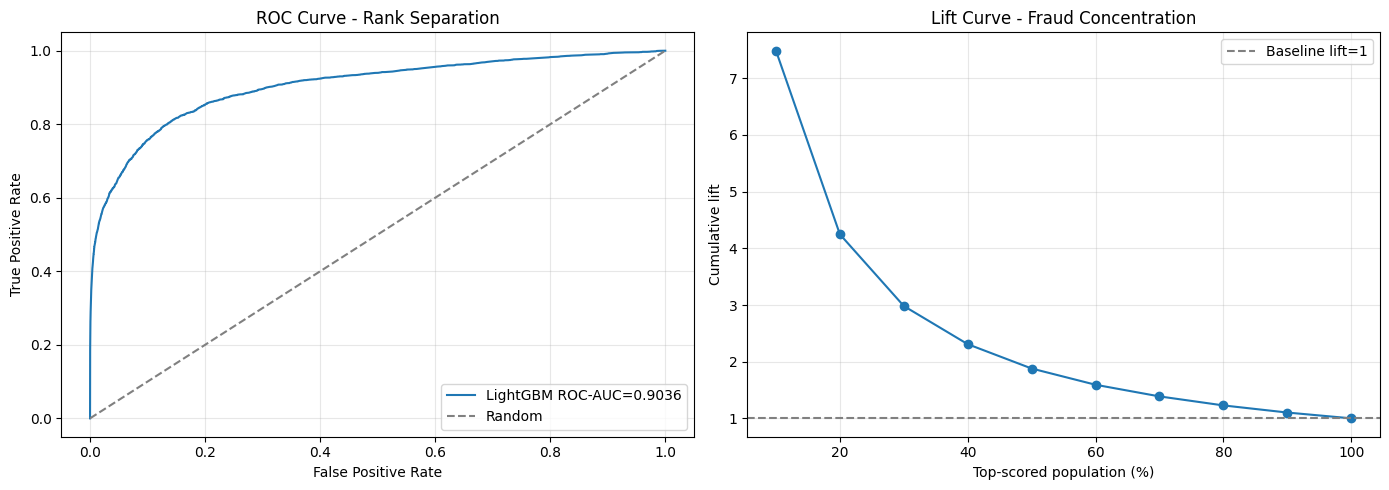

--- ROC / LIFT MONITORING ---
ROC-AUC: 0.9036
Lift @ top 10%: 7.49x
Capture rate @ top 10%: 74.87%
Lift @ top 20%: 4.25x
Capture rate @ top 20%: 84.94%


,bin,min_score,max_score,transactions,events,population_pct,event_rate,cumulative_events,cumulative_event_rate,cumulative_capture_rate,lift,cumulative_lift
0,1,0.342441,0.999713,57145,3197,0.099999,0.055945,3197,0.055945,0.748712,7.487198,7.487198
1,2,0.201354,0.342441,57146,430,0.200000,0.007525,3627,0.031735,0.849415,1.007019,4.247080
2,3,0.107002,0.201354,57145,193,0.299999,0.003377,3820,0.022282,0.894614,0.451995,2.982059
3,4,0.069349,0.107002,57146,123,0.399999,0.002152,3943,0.017250,0.923419,0.288054,2.308552
4,5,0.046520,0.069349,57146,69,0.500000,0.001207,4012,0.014041,0.939578,0.161591,1.879157
5,6,0.042131,0.046520,57145,68,0.599999,0.001190,4080,0.011899,0.955504,0.159252,1.592509
6,7,0.034641,0.042131,57146,66,0.700000,0.001155,4146,0.010365,0.970960,0.154566,1.387087
7,8,0.030444,0.034641,57145,49,0.799999,0.000857,4195,0.009176,0.982436,0.114755,1.228047
8,9,0.020326,0.030444,57146,41,0.899999,0.000717,4236,0.008236,0.992037,0.096018,1.102265
9,10,0.005850,0.020326,57146,34,1.000000,0.000595,4270,0.007472,1.000000,0.079625,1.000000


In [13]:
from src.model_eval import build_roc_curve, build_lift_curve

monitor_proba = lgb.predict_proba(Xf_test)[:, 1]
monitor_df = pd.DataFrame({
    'amount': Xf_test['amount'],
    'isFraud': yf_test,
    'prob': monitor_proba,
})

roc_df = build_roc_curve(yf_test, monitor_proba)
lift_df = build_lift_curve(monitor_df, score_col='prob', target_col='isFraud', n_bins=10)
roc_auc_monitor = float(roc_df['auc'].iloc[0])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(roc_df['fpr'], roc_df['tpr'], label=f'LightGBM ROC-AUC={roc_auc_monitor:.4f}')
axes[0].plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve - Rank Separation')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(lift_df['population_pct'] * 100, lift_df['cumulative_lift'], marker='o')
axes[1].axhline(1, linestyle='--', color='gray', label='Baseline lift=1')
axes[1].set_xlabel('Top-scored population (%)')
axes[1].set_ylabel('Cumulative lift')
axes[1].set_title('Lift Curve - Fraud Concentration')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print('--- ROC / LIFT MONITORING ---')
print(f'ROC-AUC: {roc_auc_monitor:.4f}')
print(f"Lift @ top 10%: {lift_df.loc[lift_df['bin'] == 1, 'cumulative_lift'].iloc[0]:.2f}x")
print(f"Capture rate @ top 10%: {lift_df.loc[lift_df['bin'] == 1, 'cumulative_capture_rate'].iloc[0] * 100:.2f}%")
print(f"Lift @ top 20%: {lift_df.loc[lift_df['bin'] == 2, 'cumulative_lift'].iloc[0]:.2f}x")
print(f"Capture rate @ top 20%: {lift_df.loc[lift_df['bin'] == 2, 'cumulative_capture_rate'].iloc[0] * 100:.2f}%")

display(lift_df)


Lưu Model

In [14]:
import joblib
import os

model_path = PROJECT_ROOT / 'models'
model_path.mkdir(exist_ok=True)

joblib.dump(lgb, model_path / 'LightGBM_model.pkl')
print('Model saved:', model_path / 'LightGBM_model.pkl')


Model saved: D:\Công việc\DA + DE\Book DA\Data Science for Business\PaySim\fraud-detection-paysim\models\LightGBM_model.pkl


 Áp dụng hàm tính Expected Value (EV) đã viết để xem nếu dùng mô hình này, ngân hàng tiết kiệm được bao nhiêu tiền so với cách chặn thông thường.



In [15]:
# D? li?u raw ?? ???c load ? ??u notebook v? gi? nguy?n index g?c,
# d?ng ?? so s?nh v?i rule-based baseline isFlaggedFraud.
assert 'isFlaggedFraud' in df.columns


In [16]:
from src.model_eval import decision_loss, build_profit_curve, find_best_threshold


In [17]:
# Giả lập các tham số tài chính
avg_clv = 50000000      # 50 triệu VNĐ
p_churn = 0.1           # 10% khách hàng bỏ ngân hàng nếu bị chặn nhầm (False Positive)
cost_op = 50000         # Chi phí vận hành mỗi ca
cost_fp = cost_op + (p_churn * avg_clv)

In [18]:
# Lấy sắc xuất
y_proba = lgb.predict_proba(Xf_test)[:, 1]

In [19]:
eval_df = pd.DataFrame({
    'amount': Xf_test['amount'],
    'isFraud': yf_test,
    'prob': y_proba,
    'isFlaggedFraud': df.loc[Xf_test.index, 'isFlaggedFraud'] # h? th?ng rule-based c?
})

eval_df = eval_df.sort_values('prob', ascending=False)
eval_df.head(10)


,amount,isFraud,prob,isFlaggedFraud
5188008,7703574.5,1,0.999713,0
5188009,7703574.5,1,0.999713,0
6039584,7576324.5,1,0.999713,0
5563725,9110884.0,1,0.999713,0
5563726,9110884.0,1,0.999713,0
6039583,7576324.5,1,0.999713,0
6351204,8537861.0,1,0.999710,0
5563755,9060955.0,1,0.999710,0
6272973,8488866.0,1,0.999710,0
6272972,8488866.0,1,0.999710,0


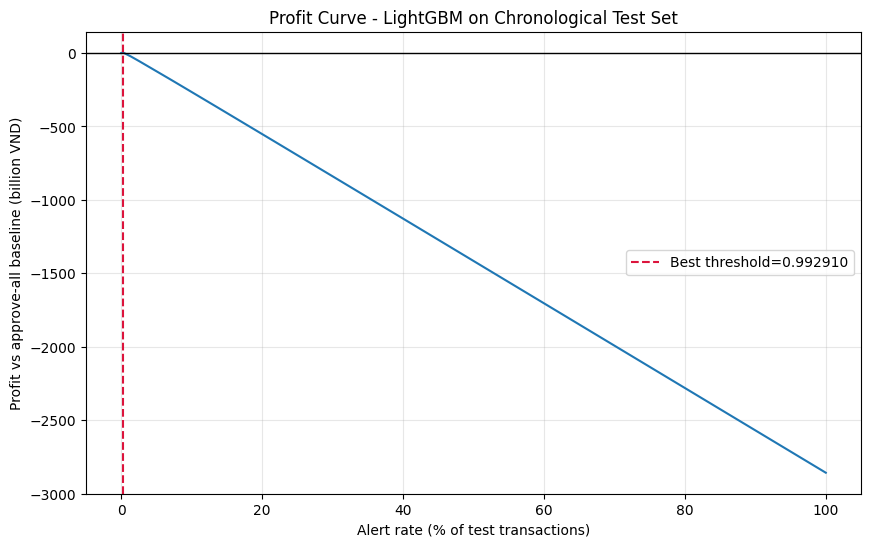

threshold                9.929097e-01
transactions             3.000000e+00
frauds                   3.000000e+00
legit                    0.000000e+00
alerted                  1.281000e+03
tp                       1.029000e+03
fp                       2.520000e+02
caught_fraud_amount      2.860291e+09
missed_fraud_amount      3.882492e+09
loss_fp                  1.272600e+09
loss                     5.155092e+09
profit_vs_approve_all    1.587691e+09
alert_rate               2.241642e-03
Name: 487, dtype: float64

In [20]:
profit_curve = build_profit_curve(
    eval_df,
    score_col='prob',
    target_col='isFraud',
    amount_col='amount',
    cost_fp=cost_fp,
)
best_threshold_row = find_best_threshold(profit_curve)
best_threshold = float(best_threshold_row['threshold'])

plt.figure(figsize=(10, 6))
plt.plot(profit_curve['alert_rate'] * 100, profit_curve['profit_vs_approve_all'] / 1e9)
plt.axvline(best_threshold_row['alert_rate'] * 100, color='crimson', linestyle='--', label=f"Best threshold={best_threshold:.6f}")
plt.axhline(0, color='black', linewidth=1)
plt.xlabel('Alert rate (% of test transactions)')
plt.ylabel('Profit vs approve-all baseline (billion VND)')
plt.title('Profit Curve - LightGBM on Chronological Test Set')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

best_threshold_row


In [21]:
eval_df['ml_decision_profit_curve'] = (eval_df['prob'] >= best_threshold).astype(int)

rule_loss = decision_loss(eval_df, 'isFlaggedFraud', cost_fp=cost_fp)
ml_loss = decision_loss(eval_df, 'ml_decision_profit_curve', cost_fp=cost_fp)
approve_all_loss = float(eval_df.loc[eval_df['isFraud'] == 1, 'amount'].sum())

saving_vs_rule = rule_loss['loss'] - ml_loss['loss']
saving_pct_vs_rule = saving_vs_rule / rule_loss['loss'] * 100
profit_vs_approve_all = approve_all_loss - ml_loss['loss']


In [22]:
print('--- PROFIT CURVE / THRESHOLD OPTIMIZATION ---')
print(f"False-positive cost used in matrix: {cost_fp:,.0f}")
print(f"Best threshold: {best_threshold:.8f}")
print(f"Alert rate at best threshold: {best_threshold_row['alert_rate'] * 100:.4f}%")
print(f"Flagged transactions: {int(best_threshold_row['alerted']):,}")
print(f"TP: {int(best_threshold_row['tp']):,} | FP: {int(best_threshold_row['fp']):,}")
print()
print('--- COST-ONLY MATRIX, NO TP/FN DOUBLE COUNTING ---')
print(f"Approve-all loss: {approve_all_loss:,.0f}")
print(f"Rule-based loss: {rule_loss['loss']:,.0f} | FN loss: {rule_loss['loss_fn']:,.0f} | FP loss: {rule_loss['loss_fp']:,.0f}")
print(f"ML optimized loss: {ml_loss['loss']:,.0f} | FN loss: {ml_loss['loss_fn']:,.0f} | FP loss: {ml_loss['loss_fp']:,.0f}")
print(f"Saving vs rule: {saving_vs_rule:,.0f} ({saving_pct_vs_rule:.2f}%)")
print(f"Profit vs approve-all: {profit_vs_approve_all:,.0f}")


--- PROFIT CURVE / THRESHOLD OPTIMIZATION ---
False-positive cost used in matrix: 5,050,000
Best threshold: 0.99290966
Alert rate at best threshold: 0.2242%
Flagged transactions: 1,281
TP: 1,029 | FP: 252

--- COST-ONLY MATRIX, NO TP/FN DOUBLE COUNTING ---
Approve-all loss: 6,742,784,000
Rule-based loss: 6,671,831,552 | FN loss: 6,671,831,552 | FP loss: 0
ML optimized loss: 5,155,092,480 | FN loss: 3,882,492,416 | FP loss: 1,272,600,000
Saving vs rule: 1,516,739,072 (22.73%)
Profit vs approve-all: 1,587,691,520


Kết hợp với Quyết định 2345 (ngưỡng 10 triệu) trên tập dữ liệu kiểm thử. Thống kê xem có bao nhiêu % giao dịch bị yêu cầu sinh trắc học, bao nhiêu % bị chặn.


In [23]:
# Deployment-style intervention summary using the optimized threshold.
# Raw probability bands such as 0.5 are intentionally not used.


In [24]:
results_df = pd.DataFrame({
    'amount': Xf_test['amount'],
    'prob': y_proba,
})


In [25]:
def get_deploy_decision(row):
    if row['prob'] >= best_threshold:
        return 'Model alert: review/step-up'
    if row['amount'] >= 10000000:
        return 'Q? 2345: Sinh tr?c h?c FaceID'
    return 'Auto approve'

results_df['decision'] = results_df.apply(get_deploy_decision, axis=1)


In [26]:
stats = results_df['decision'].value_counts(normalize=True) * 100


In [27]:
print()
print('--- INTERVENTION SUMMARY WITH OPTIMIZED THRESHOLD ---')
print(f"Deploy threshold: {best_threshold:.8f}")
print(f"Auto approve: {stats.get('Auto approve', 0):.2f}%")
print(f"QD 2345 FaceID: {stats.get('Q? 2345: Sinh tr?c h?c FaceID', 0):.2f}%")
print(f"Model alert: {stats.get('Model alert: review/step-up', 0):.2f}%")



--- INTERVENTION SUMMARY WITH OPTIMIZED THRESHOLD ---
Deploy threshold: 0.99290966
Auto approve: 99.73%
QD 2345 FaceID: 0.04%
Model alert: 0.22%
